# Introduction

A group of UBC computer science students, named The Pacific Laboratory for Artificial Intelligence (PLAI), are conducting research on player actions in their own MineCraft server, PLAIcraft. This is being done with hopes of developing an advanced AI tool, also known as embodied AI, to implement in the video game. Additionally, supporting the server requires adequate information about the amount and type of players for recruitment efforts. As such, data on players and their gameplay is being collected through this MineCraft server.  


**General question:**
What player characteristics and behaviours are most predictive of subscribing to a game-related newsletter, and how do these features differ between various player types?


**Predictive Question:** Does player age and number of sessions predict whether they will subscribe in a game-related newsletter?

To answer this question, we will use two files: players.csv and sessions.csv. Which together, capture the characteristics and game behaviors on the PLAIcraft Minecraft Server. 

The players.csv dataset contains 196 observations with each row representing a unique player and includes seven variables describing player demographics and characteristics. 

These variables include: 
- **experience** (qualitative), which categorizes the player’s experience level across 5 levels 
- **subscribe** (qualitative), a TRUE / FALSE indicator of whether the player is subscribed to the news letter 
- **hashedEmail** (qualitative), a unique identifier for each player 
- **played_hours** (quantitative), a numeric value representing the total hours each player has spent on the server
- **name** (qualitative), the player’s displayed name
- **gender** (qualitative), recorded as one of 6 categories (Male, Female, Non-binary, Prefer not to say, Other, Two-Spirited) 
- **Age** (quantitative), a numeric value of the player’s age in years

The sessions.csv dataset contains essential behavioral data with 1,525 observations, with each row representing an individual playing session in the server. This means that a single player may appear multiple times in the dataset. The dataset includes five variables:

- **hashedEmail** (qualitative), a unique identifier for each player (same as players.csv)
- **start_time** (qualitative), the timestamp when the session began (date and time) 
- **end_time** (qualitative), the timestamp when the session ended (data and time)
- **original_start_time** (quantitative), raw unfiltered time stamp when the session began (epoch timestamp) 
- **original_end_time** (quantitative), raw unfiltered time stamp when the session ended (epoch timestamp)

To address our predictive question, we will combine the datasets into one using the shared hashedEmail identifier variable and then use the variables Age and session_count as the predictor variables, with subscribe as the response variable. Before combining the players.csv and sessions.csv datatsets, the session_count variable will be generated from the sessions.csv dataset by counting the total number of sessions associated with each player’s hashedEmail.

## Data Description (subtitle tbd)

In [2]:
library(tidyverse)
library(tidymodels)
library(themis)
set.seed(1234)
players <- read_csv("https://raw.githubusercontent.com/chrispy-tacos/dsci-100-project/refs/heads/main/players.csv")
sessions <- read_csv("https://raw.githubusercontent.com/chrispy-tacos/dsci-100-project/refs/heads/main/sessions.csv")

sessions_compressed <- sessions |>
    select(hashedEmail) |>
    group_by(hashedEmail) |>
    summarize(session_count = n())

combined_data <- players |>
    inner_join(sessions_compressed)

head(combined_data)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
── Attaching packages ────────────────────────────────────── tidymodels 1.1.1 ──

✔ broom        1.0.6     ✔ rsample      1.2.1
✔ dials        1.3.0     ✔ tune         1.1.2
✔ infer        1.0.7     ✔ workflows    1.1.4
✔ modeldata    1.4.0     ✔ workflowsets 1.0.1
✔ parsnip      1.2.1     ✔ yardstick    1.3.1
✔ recipes      1.1.0     

── Conflicts ───────────────────────────────────────── tidymodels_conflicts() ──
✖ scales::discard() masks purrr::discard()
✖ dplyr::filt

experience,subscribe,hashedEmail,played_hours,name,gender,Age,session_count
<chr>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<int>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9,27
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17,3
Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17,1
Amateur,TRUE,23fe711e0e3b77f1da7aa221ab1192afe21648d47d2b4fa7a5a659ff443a0eb5,0.7,Flora,Female,21,1
Regular,TRUE,7dc01f10bf20671ecfccdac23812b1b415acd42c2147cb0af4d48fcce2420f3e,0.1,Kylie,Male,21,1
Amateur,FALSE,1d2371d8a35c8831034b25bda8764539ab7db0f63938696917c447128a2540dd,0.0,Emerson,Male,21,1


## Summary statistics

We will now acquire relevant summary statistiscs for our analysis from the combined dataset created above. We would like to look at the median and mean of player age, as well as the mean # of session per player.

In [3]:
# summary of player ages
summary_age <- players |>
    mutate(avg_age = mean(Age, na.rm = TRUE), 
            med_age = median(Age, na.rm = TRUE)) |>
    select(avg_age, med_age) |>
    slice(1) |>
    mutate(avg_age = round(avg_age, 2))
summary_age

avg_age,med_age
<dbl>,<dbl>
21.14,19


**Table 1.** The average age is roughly 21 years old while the median is 19. This suggests that we have majority individuals in their teens and twenties participating.

In [4]:
# summary of player sessions
summary_session <- combined_data |>
        mutate(avg_session = mean(session_count), na.rm = TRUE) |>
        select(avg_session) |>
        slice(1) |>
        mutate(avg_session = round(avg_session, 2))
summary_session

avg_session
<dbl>
12.28


**Table 2.** The average was roughly 12 sessions per player.

# Methods

## Determining the method for data analysis 

In [5]:
minecraft_clean<- combined_data|> 
drop_na(Age, session_count)

The data was cleaned to drop any NA values for the following steps. This makes the data have an equal amount of predictors for the bind_cols function that will be used to analyze the strength of our model. 

In [6]:
subscribe_count<- minecraft_clean|> 
count(subscribe)

subscribe_count

subscribe,n
<lgl>,<int>
FALSE,32
TRUE,91


**Table 3.** The above code checks the balance of the data. From the table we can see that the TRUE label is overrepresented in the data set (3:1 ratio) and therefore there is an inbalance in the data. These results indicate that we should rebalance the data for more accurate results after checking for linearity between our variables. 

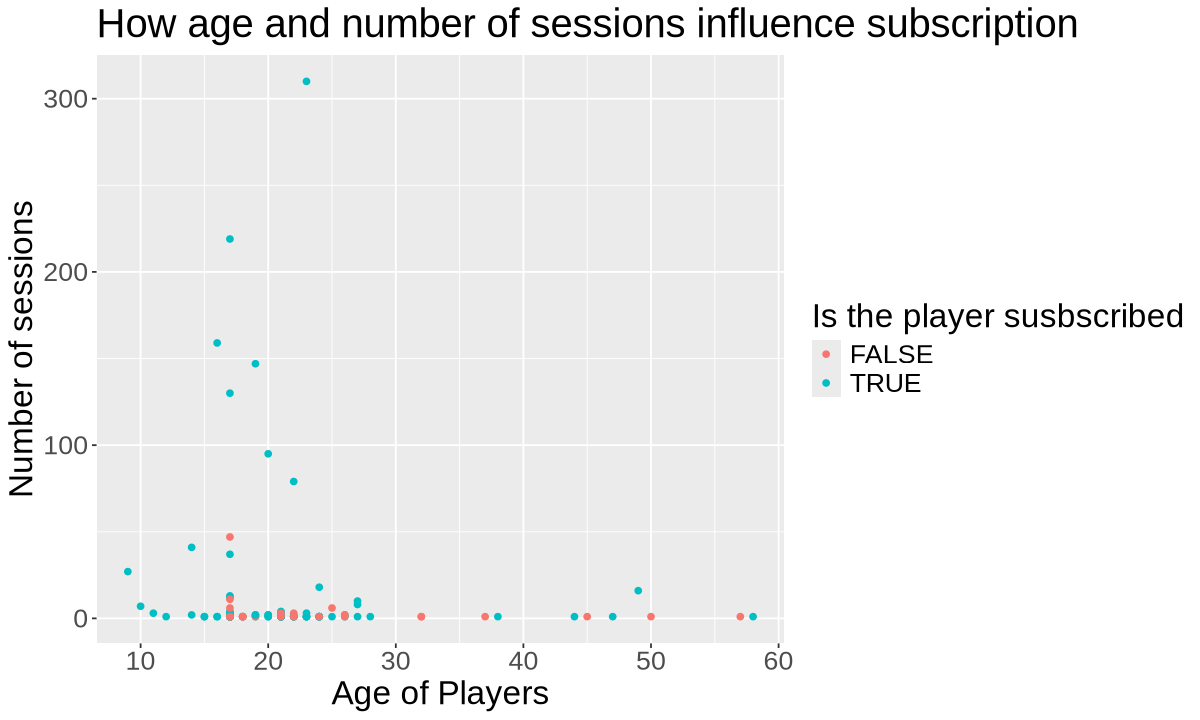

In [7]:
options(repr.plot.width=10, repr.plot.height=6)

plot_of_age_vs_subscription<- ggplot(minecraft_clean, aes(x = Age, y = session_count))+
geom_point(aes(colour = subscribe))+ 
xlab("Age of Players")+ 
ylab("Number of sessions")+ 
ggtitle("How age and number of sessions influence subscription")+
labs(colour= "Is the player susbscribed")+
theme(text = element_text(size = 20))

plot_of_age_vs_subscription

**Figure 1.** To determine which predictive model to use in our analysis we visualized our variables to see if there was a linear relationship. This data was then plotted using age on the x-axis, session_count on the y-axis, and colouring the data points based on subscription status. The plot shows that there is not a linear relationship between the two variables and therefore using a linear regression model would not improve the analysis. Therefore, Figure 1 indicates that we should use K-NN classification to understand the relationship between age and session_count. 

## Renaming the Subscribe observations and balancing the data 

In [8]:
minecraft_clean <- minecraft_clean |>
  mutate(subscribe = factor(subscribe))




The above code changes the outcome variable to a factor. This is important because the K-NN classification models require that the output variable is a factor with clearly defined labels. The original output variables (TRUE and FALSE) are logical and therefore are not able to be used in the classification model unless changed.

## Splitting the data for training and analysis 

In [9]:
minecraft_split<- initial_split(minecraft_clean, prop = 0.75, strata = subscribe)
minecraft_training<- training(minecraft_split) 
minecraft_testing<- testing(minecraft_split)

The above code shows how we split the data into a training set and a testing set to use on the model. The training set will be used to train the model and determine the best K value and then the testing data is used to study the accuracy, specificity, and sensitivity of the model. 

## Making a recipe

In [10]:
minecraft_vfold<- vfold_cv(minecraft_training, v= 5, strata = subscribe)

Prior to creating a recipe a cross validation object is set. The cross validation improves the K-NN model and evaluates the K value in order to choose the best K. 

In [11]:
minecraft_recipe<- recipe(subscribe ~ Age + session_count, data = minecraft_training)|> 
step_scale(Age, session_count)|> 
step_center(Age, session_count)|> 
step_upsample(subscribe)

minecraft_recipe



── Recipe ──────────────────────────────────────────────────────────────────────



── Inputs 

Number of variables by role

outcome:   1
predictor: 2



── Operations 

• Scaling for: Age and session_count

• Centering for: Age and session_count

• Up-sampling based on: subscribe



The above code creates a recipe for the K-NN model we are creating and evaluating. The first line of code specifies the output variable as well as the predictor variables Age and session_count. This is applied to the training data set. The data is also scaled, centered, and rebalanced in the code following in order to limit the bias in our model. Scaling the data is done as the model uses Euclidean distances, this process ensures that the standard deviation is 1 for both variables and limits a bias to the larger scale value. The data is centered in order to ensure all the variables have a mean of zero, this ensures that the distances measured are meaningful. Lastly, we rebalance the data for the variable subscribe in order to get an unbiased sensitivity. 

## Creating the K-NN classifier 

In [12]:
minecraft_knn_spec<- nearest_neighbor(weight_func = "rectangular", neighbors = tune())|> 
set_engine("kknn") |> 
set_mode("classification")
minecraft_knn_spec

K-Nearest Neighbor Model Specification (classification)

Main Arguments:
  neighbors = tune()
  weight_func = rectangular

Computational engine: kknn 


In [13]:
k_vals<- tibble(neighbors = seq(from = 1, to = 45, by=2))

knn_k_specification_results<- workflow()|> 
add_recipe(minecraft_recipe)|> 
add_model(minecraft_knn_spec)|>
tune_grid(resamples = minecraft_vfold, grid = k_vals)|> 
collect_metrics()


head(knn_k_specification_results)

neighbors,.metric,.estimator,mean,n,std_err,.config
<dbl>,<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>
1,accuracy,binary,0.5965256,5,0.01934357,Preprocessor1_Model01
1,roc_auc,binary,0.6089560,5,0.02295849,Preprocessor1_Model01
3,accuracy,binary,0.5315445,5,0.02463136,Preprocessor1_Model02
3,roc_auc,binary,0.6392857,5,0.02744174,Preprocessor1_Model02
5,accuracy,binary,0.4888545,5,0.02588613,Preprocessor1_Model03
5,roc_auc,binary,0.6404396,5,0.03219405,Preprocessor1_Model03


**Table 4.** The table above shows the K values tested, their respective accuracies and how well the model ranks the positive and negative cases. The mean column corresponds to the mean accuracy and roc_auc mean across the 5 fold cross validation and then the standard error is displayed as well. The roc_auc helps us understand the predictive power of our model by indicating how well the model seperates between TRUE and FALSE classes at any possible threshold. This data can be graphed as seen below to help identify the best K value for the model and additional K values that may be worth testing. 

## Graph of the K values 

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_line()`).”


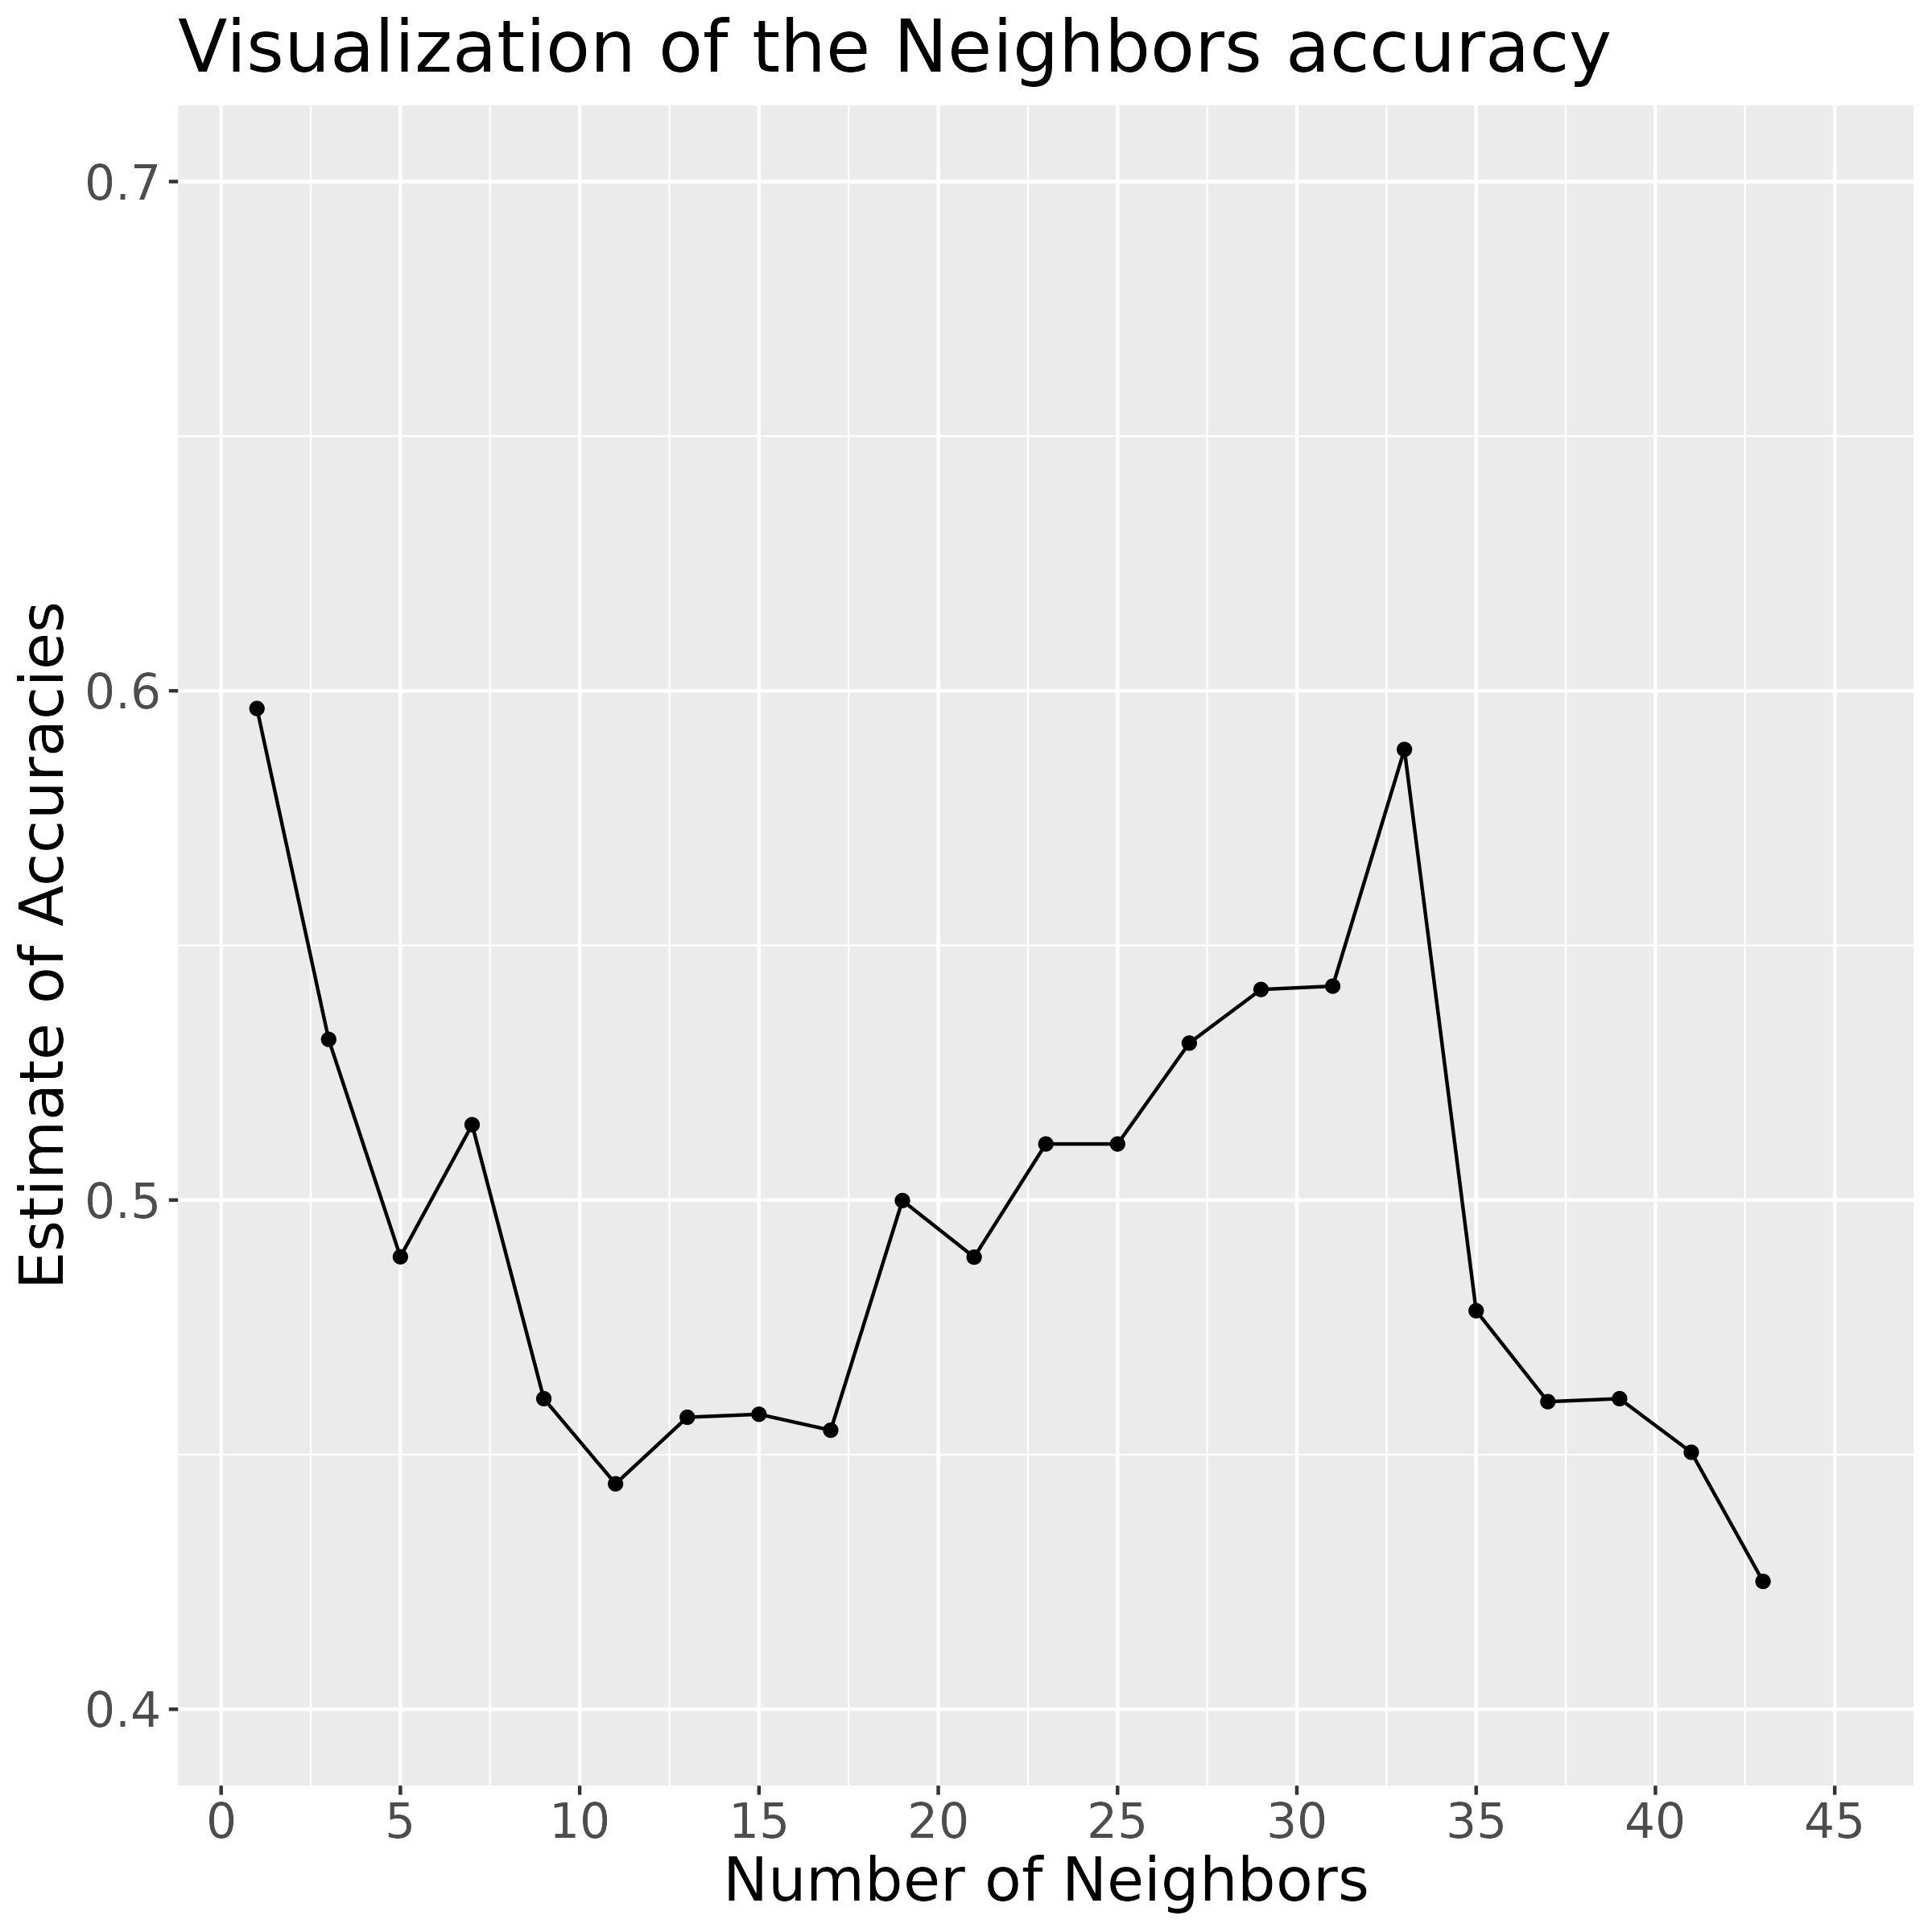

In [18]:
minecraft_accuracy<- knn_k_specification_results|> 
filter(.metric == "accuracy")

plot_of_k_values<- ggplot(minecraft_accuracy, aes(x = neighbors, y = mean))+ 
geom_point()+ 
geom_line()+ 
xlab("Number of Neighbors")+ 
ylab("Estimate of Accuracies")+ 
ggtitle("Visualization of the Neighbors accuracy")+
scale_x_continuous(breaks = seq(0, 55, by = 5)) +  
       scale_y_continuous(limits = c(0.4, 0.7))+
theme(text = element_text(size = 18))

ggsave("plot_of_k_values.png", plot = plot_of_k_values, width = 8, height = 8, dpi = 300)

IRdisplay::display_png(file = "plot_of_k_values.png")


**Figure 2.** The figure above graphs the number of K values versus the estimate of accuracy. From the graph it is observed that K = 1 has the highest accuracy and therefore is the best K value to use in the K-NN classification model. 

## Graph of roc auc

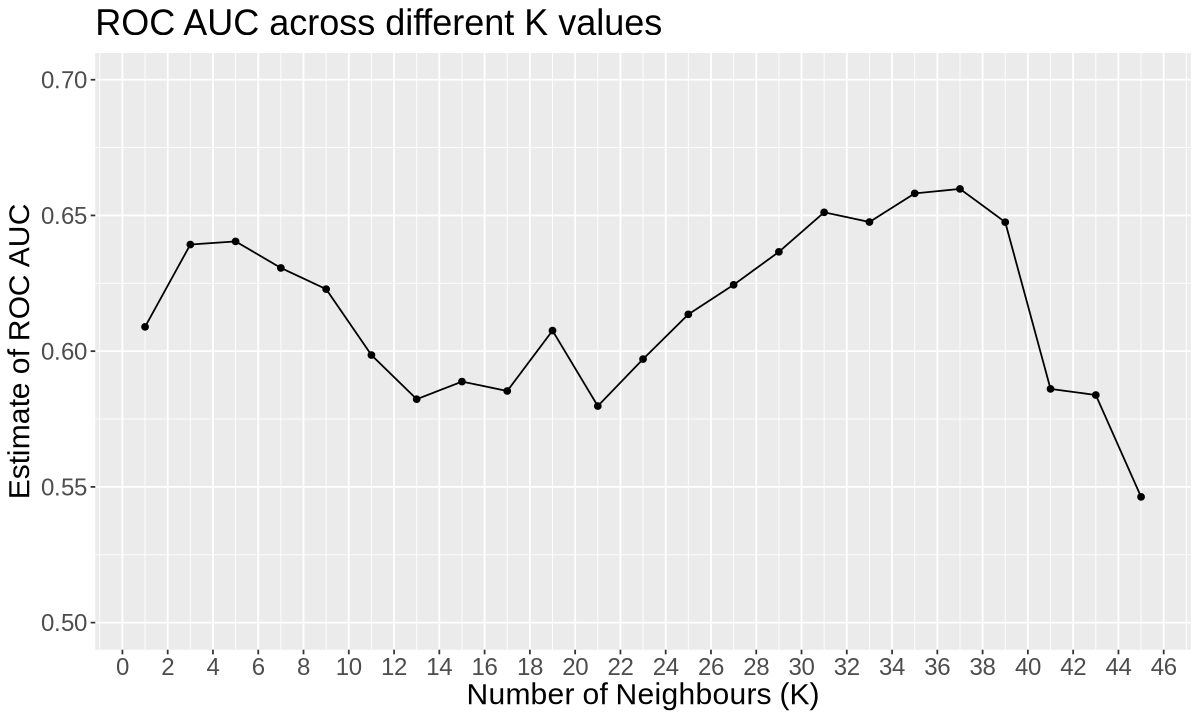

In [24]:
plot_of_roc_auc<- knn_k_specification_results|> 
filter(.metric == "roc_auc")|> 
ggplot(aes(x = neighbors, y = mean))+ 
geom_point()+ 
geom_line()+ 
xlab("Number of Neighbours (K)")+ 
ylab("Estimate of ROC AUC")+
ggtitle("ROC AUC across different K values")+
scale_x_continuous(breaks = seq(0, 55, by = 2)) +  
       scale_y_continuous(limits = c(0.5, 0.7))+
theme(text = element_text(size = 18))

plot_of_roc_auc

**Figure 3.** The graph above is a plot of the K values agaisn't the mean of roc_auc. The graph display the K values predictive power from distinguishing between TRUE and FALSE classes against any threshhold. The values for this metric range from 0-1, where 1 is a perfect model and 0.5 indicates that the model is no better than random. Given this graph we could also try to use K = 38 for our model to see if it has better accuracy and kap on the testing data.  

## Using the Model on Testing data 

In [15]:
minecraft_recipe_final<- recipe(subscribe ~ Age + session_count, data = minecraft_training)

minecraft_knn_spec_k<- nearest_neighbor(weight_func = "rectangular", neighbors = 1)|> 
set_engine("kknn")|> 
set_mode("classification")

minecraft_fit<- workflow()|> 
add_recipe(minecraft_recipe_final)|> 
add_model(minecraft_knn_spec_k)|> 
fit(data = minecraft_training)

minecraft_predictions<- predict(minecraft_fit, new_data = minecraft_testing) |> 
bind_cols(minecraft_testing)

minecraft_metrics<- minecraft_predictions|> 
metrics(truth = subscribe, estimate = .pred_class)

minecraft_metrics

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
accuracy,binary,0.3548387
kap,binary,-0.2704918


**Table 5.** Here we use k = 1 to create our best (in terms of accuracy; Figure 2) model spec. We then combine this model spec with the same recipe as before into a workflow, and fit it to the training dataset to create the classifier. Lastly, we are applying this classifier to the testing dataset to get predictions on player subscription, binding these predictions to the testing data set so that accuracy of the predictions is evaluated against the "true" player subscription. These metrics are shown in the output of the above cell. The accuracy tells us what proportions of predictions the model got correct, from our data we observe that the model is only correct 35% of the time. Additionally, kap (stands for Cohen's Kappa), represents the metric that indicates how good our model is compared to random guessing. The metric ranges from -1 to 1, where 1 indicates a perfect model and anythign below 0 indicates that the model is worse than random guessing. As our kap value is -0.27 and we have an accuracy of 35% this indicates that our model doesn't perform well. 

In [27]:
minecraft_conf_mat<- minecraft_predictions|> 
conf_mat(truth = subscribe, estimate = .pred_class)

minecraft_conf_mat

          Truth
Prediction FALSE TRUE
     FALSE     2   14
     TRUE      6    9

This confusion matrix shows what type of mistakes were made by our classifier. We see that it falsely classified 6 players as subscribed when they weren't, and 14 as not subscribed when they were. This is also shown by the heatmap below. 

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


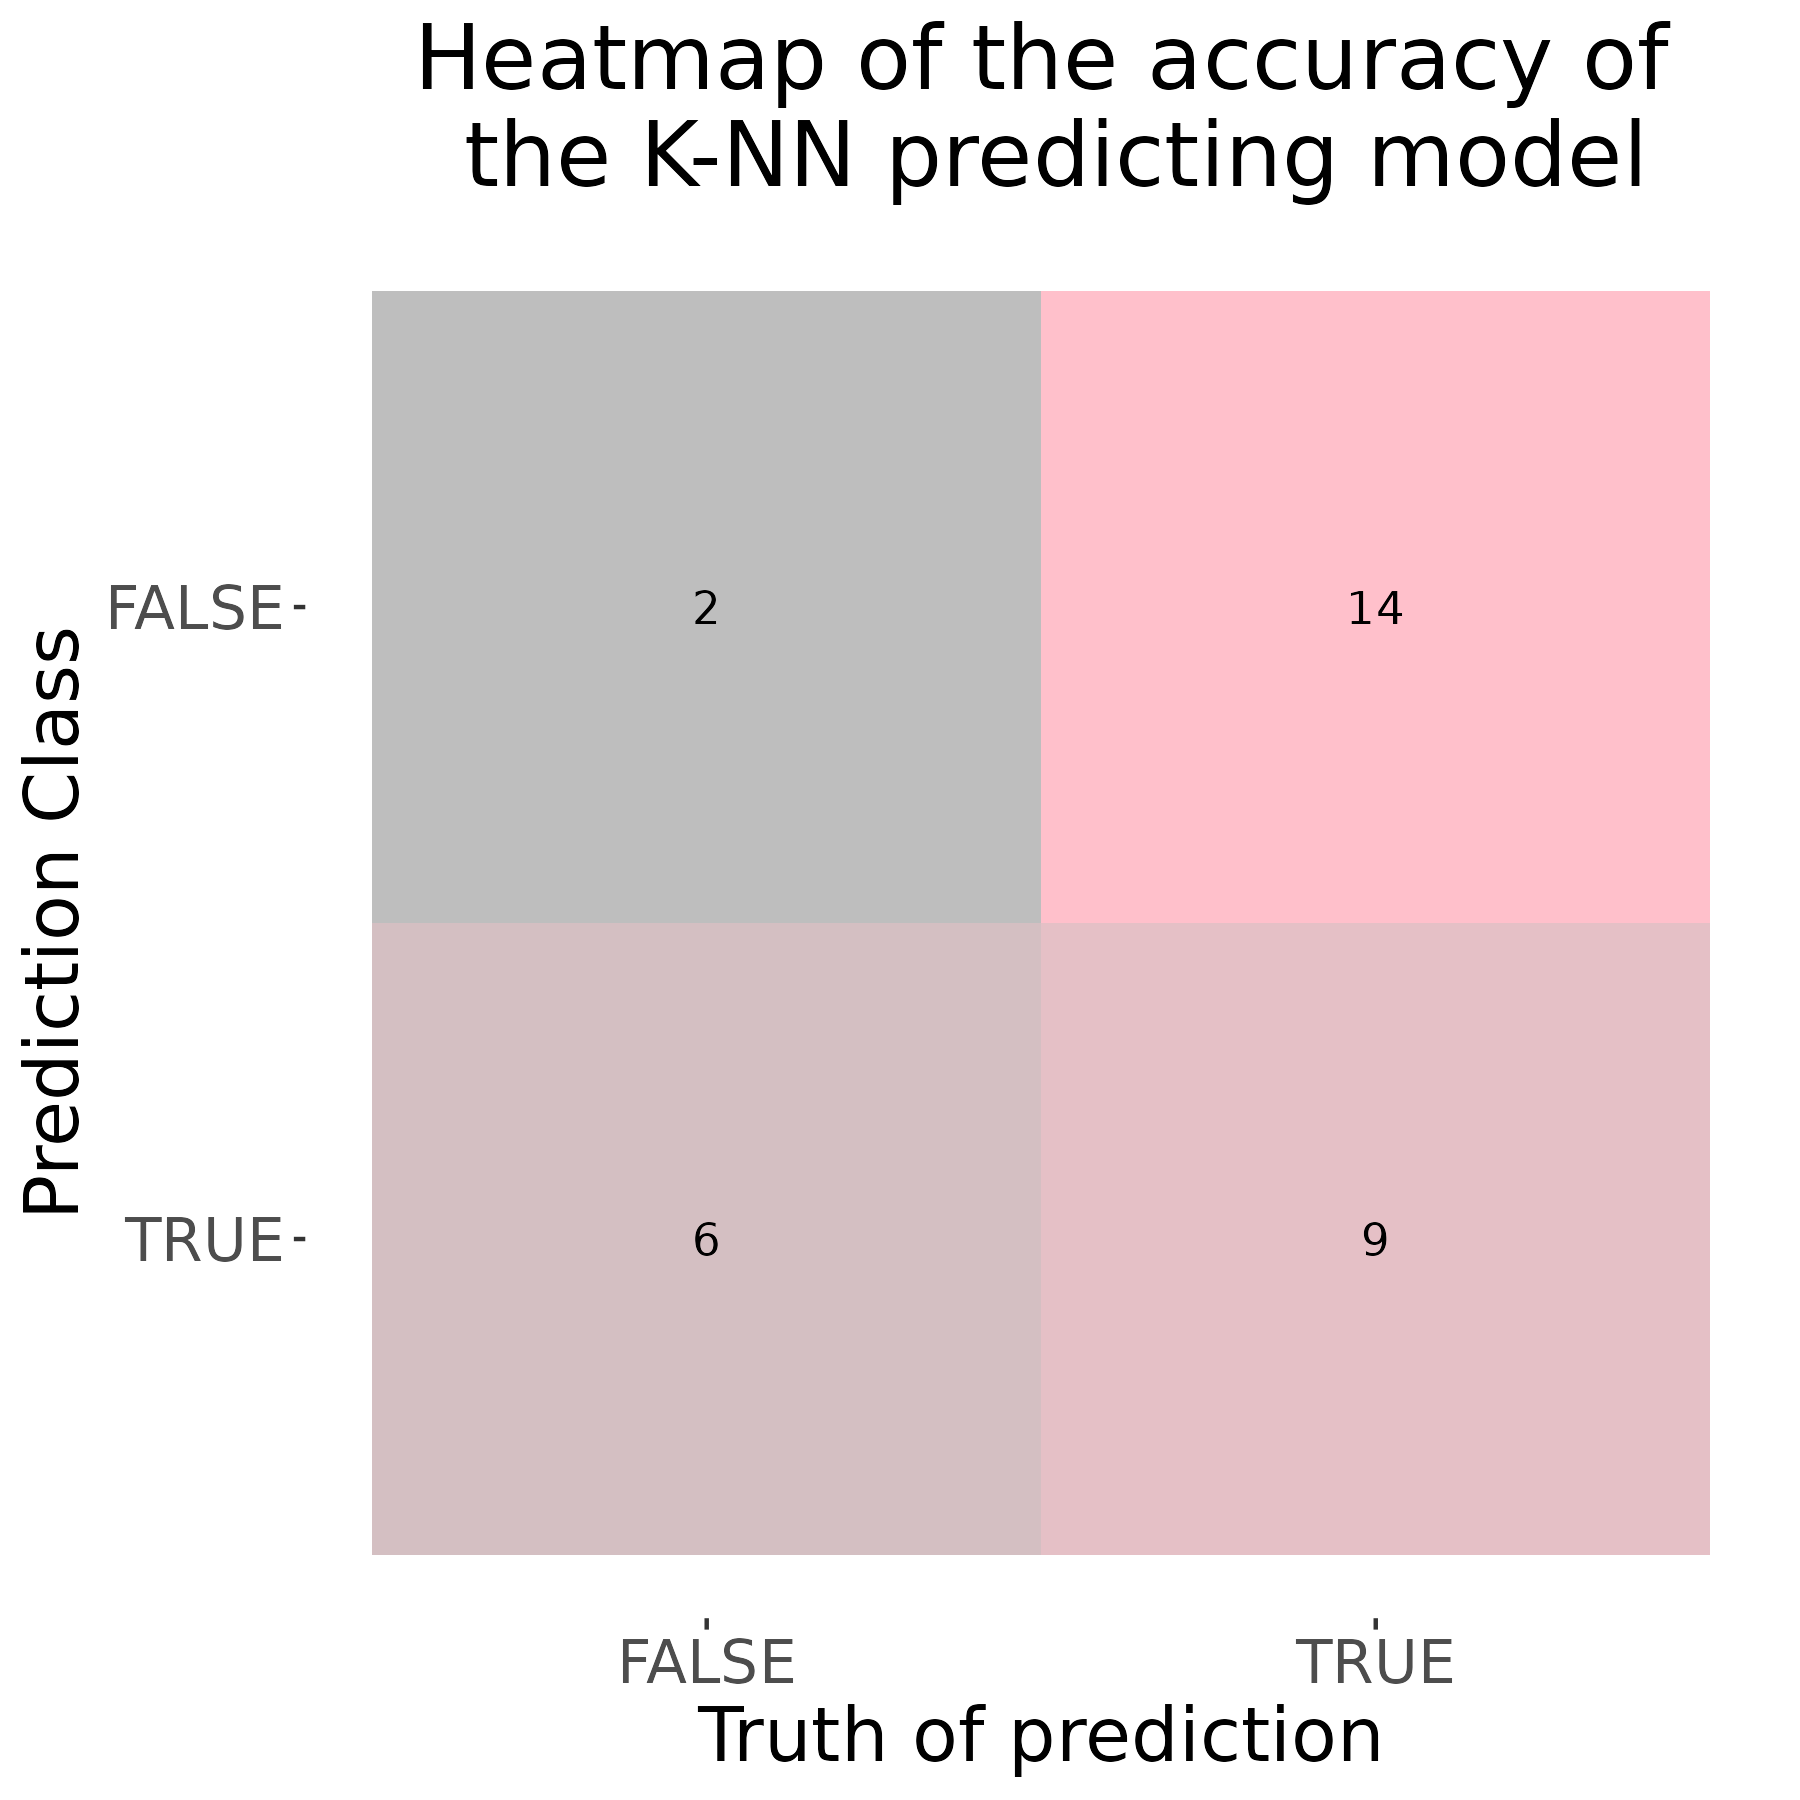

In [17]:
minecraft_conf_mat_heatmap<- minecraft_predictions|> 
conf_mat(truth = subscribe, estimate = .pred_class)|> 
autoplot(type = "heatmap")+ 
scale_fill_gradient(low = "grey", high = "pink")+ 
labs(x = "Truth of prediction", y= "Prediction Class", title = "Heatmap of the accuracy of\n the K-NN predicting model")+ 
theme(text = element_text(size = 18), 
    plot.title = element_text(hjust = 0.5))

ggsave("minecraft_conf_mat_heatmap.png", plot = minecraft_conf_mat_heatmap, width = 6, height = 6, dpi = 300)

IRdisplay::display_png(file = "minecraft_conf_mat_heatmap.png")

**Figure 4.** The heatmap above visualizes how well our model predicted on the testing data. From the visualization we can see that it generated 6 false positives, predicting subsription when the player was in fact not subscribed and 14 false negative, predicting not subscribed when the player was subscribed. 